# Sensor Fusion Tabanlı Karar Destek ve Tehdit Önceliklendirme Sistemi

**Endüstri Mühendisliği – Çok Sensörlü Veri Füzyonu ve Çok Kriterli Karar Verme (ÇKKV)**

Bu projede, birden fazla sensörden (radar, kızılötesi/IR, elektro-optik/görüntü) gelen **gürültülü ve
kısmen çelişen ölçümler**, **sensör füzyonu (Kalman Filtresi)** ile tek bir tutarlı durum tahminine
(konum, hız, güven skoru) dönüştürülmektedir. Elde edilen füzyon çıktıları, ardından bir
**Çok Kriterli Karar Verme (ÇKKV) yöntemi olan TOPSIS** ile değerlendirilerek nesneler
**tehdit önceliğine göre sıralanmakta** ve bir karar destek panosu (dashboard) üretilmektedir.

> Not: Bu çalışmadaki tüm sensör verileri **sentetik (simüle edilmiş)** olarak üretilmiştir;
> gerçek bir sensör, silah veya operasyonel sistemle bağlantısı yoktur. Amaç, veri füzyonu ve
> çok kriterli karar verme yöntemlerinin uçtan uca bir karar destek sistemi içinde nasıl
> bütünleştirilebileceğini göstermektir.

## Proje Sahibi
Ceren Gündüz — Endüstri Mühendisliği, 4. Sınıf

## İçindekiler
1. Problem Tanımı ve Sistem Mimarisi
2. Sentetik Çok Sensörlü Veri Üretimi
3. Sensör Füzyonu (Kalman Filtresi ile Durum Tahmini)
4. Tehdit Skorlama — Çok Kriterli Karar Verme (TOPSIS)
5. Karar Destek Panosu (Görselleştirme)
6. Sonuç ve Değerlendirme


## 1. Problem Tanımı ve Sistem Mimarisi

Bir izleme alanında (ör. bir hava sahası / güvenlik bölgesi) birden fazla nesne (İHA, sivil hava aracı,
bilinmeyen cisim vb.) farklı sensörler tarafından eş zamanlı olarak algılanmaktadır. Her sensörün
ölçüm hatası ve güvenilirliği farklıdır. Sistem şu adımlardan oluşur:

1. **Algılama (Sensing):** Radar, IR ve görüntü sensörlerinden gürültülü konum/hız ölçümleri.
2. **Füzyon (Fusion):** Kalman filtresi ile ölçümlerin birleştirilip tek bir durum tahmini üretilmesi.
3. **Değerlendirme (Assessment):** Füzyon çıktısına dayanan kriterlerin (mesafe, hız, güven skoru,
   nesne tipi risk katsayısı) TOPSIS yöntemiyle tek bir **öncelik skoruna** indirgenmesi.
4. **Karar Destek:** Nesnelerin önceliğe göre sıralandığı bir pano ile operatöre özet sunulması.

Bu, endüstri mühendisliğinde klasik bir **veri füzyonu + ÇKKV tabanlı karar destek sistemi**
mimarisidir; aynı yaklaşım hava trafik önceliklendirme, afet müdahale kaynak tahsisi veya
üretimde arıza önceliklendirme gibi alanlara da uyarlanabilir.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True


## 2. Sentetik Çok Sensörlü Veri Üretimi

In [2]:
# İzlenen nesneler (sentetik senaryo)
nesneler = pd.DataFrame({
    'ID': ['N1', 'N2', 'N3', 'N4', 'N5', 'N6'],
    'Tip': ['Bilinmeyen Cisim', 'İHA', 'Sivil Uçak', 'İHA', 'Bilinmeyen Cisim', 'Sivil Uçak'],
    # Tip bazlı temel risk katsayısı (0-1) - senaryo varsayımı
    'Tip_Risk_Katsayisi': [0.9, 0.7, 0.2, 0.7, 0.9, 0.2],
    # Gerçek (bilinmeyen/gizli) konum ve hız - simülasyon amaçlı
    'Gercek_Mesafe_km': [12, 35, 80, 22, 60, 95],
    'Gercek_Hiz_kmh': [340, 180, 820, 260, 90, 900],
})
nesneler


,ID,Tip,Tip_Risk_Katsayisi,Gercek_Mesafe_km,Gercek_Hiz_kmh
0,N1,Bilinmeyen Cisim,0.9,12,340
1,N2,İHA,0.7,35,180
2,N3,Sivil Uçak,0.2,80,820
3,N4,İHA,0.7,22,260
4,N5,Bilinmeyen Cisim,0.9,60,90
5,N6,Sivil Uçak,0.2,95,900


In [3]:
def sensor_olcumleri_uret(gercek_mesafe, gercek_hiz, n_adim=10):
    """Her nesne için 3 sensörden (radar, IR, görüntü) n_adim zaman adımında
    gürültülü mesafe/hız ölçümü üretir. Sensörlerin gürültü seviyeleri farklıdır.
    """
    zaman = np.arange(n_adim)
    veriler = []
    for t in zaman:
        # Radar: mesafe/hız ölçümünde görece güvenilir
        radar_mesafe = gercek_mesafe - 0.5 * t + np.random.normal(0, 1.5)
        radar_hiz = gercek_hiz + np.random.normal(0, 8)
        # IR: kısa menzilde daha iyi, gürültü mesafeyle artar
        ir_mesafe = gercek_mesafe - 0.5 * t + np.random.normal(0, 1.5 + 0.02 * gercek_mesafe)
        ir_hiz = gercek_hiz + np.random.normal(0, 15)
        # Görüntü (EO): hız tahmininde daha gürültülü, mesafede orta seviye
        eo_mesafe = gercek_mesafe - 0.5 * t + np.random.normal(0, 2.5)
        eo_hiz = gercek_hiz + np.random.normal(0, 25)

        veriler.append([t, radar_mesafe, radar_hiz, ir_mesafe, ir_hiz, eo_mesafe, eo_hiz])

    return pd.DataFrame(veriler, columns=[
        'zaman', 'radar_mesafe', 'radar_hiz', 'ir_mesafe', 'ir_hiz', 'eo_mesafe', 'eo_hiz'
    ])

sensor_verileri = {
    row.ID: sensor_olcumleri_uret(row.Gercek_Mesafe_km, row.Gercek_Hiz_kmh)
    for row in nesneler.itertuples()
}

sensor_verileri['N1'].head()


,zaman,radar_mesafe,radar_hiz,ir_mesafe,ir_hiz,eo_mesafe,eo_hiz
0,0,14.535789,336.272501,12.057107,346.112744,10.027692,340.051639
1,1,11.498664,325.962206,13.270725,349.007478,9.936428,335.711293
2,2,11.757949,337.909149,10.577617,318.201379,12.386451,343.097023
3,3,10.911690,327.787804,13.372217,342.315033,9.532150,390.726806
4,4,9.931921,328.394570,9.294904,305.675273,12.623491,329.588142


## 3. Sensör Füzyonu (Kalman Filtresi ile Durum Tahmini)

Üç sensörden gelen mesafe ölçümleri, basit bir **1 boyutlu Kalman filtresi** ile ardışık olarak
füzyonlanarak her nesne için tek, gürültüsü azaltılmış bir **mesafe ve hız tahmini** elde edilir.
Ayrıca sensörler arasındaki **tutarlılık** (ölçüm varyansı), o nesne için genel bir **füzyon güven
skoruna** dönüştürülür — sensörler birbiriyle ne kadar uyumluysa güven o kadar yüksek olur.


In [4]:
def kalman_fuzyonu(df):
    """3 sensörün mesafe ölçümlerini basit bir Kalman filtresi ile füzyonlar.
    Durum: [mesafe, hiz]. Her zaman adımında 3 sensörün mesafe ölçümü ardışık
    olarak güncelleme (update) adımında kullanılır.
    """
    dt = 1.0
    F = np.array([[1, dt], [0, 1]])          # durum geçiş matrisi
    Q = np.array([[0.05, 0], [0, 0.05]])      # süreç gürültüsü
    H = np.array([[1, 0]])                    # ölçüm matrisi (sadece mesafe ölçülüyor)

    x = np.array([[df.iloc[0][['radar_mesafe', 'ir_mesafe', 'eo_mesafe']].mean()], [0]])
    P = np.eye(2) * 10

    sensor_R = {'radar_mesafe': 2.0, 'ir_mesafe': 4.0, 'eo_mesafe': 6.0}  # sensör ölçüm gürültü varyansları

    mesafe_tahmini, hiz_tahmini = [], []
    for _, row in df.iterrows():
        # Tahmin (predict) adımı
        x = F @ x
        P = F @ P @ F.T + Q

        # Her sensörden gelen ölçümle ardışık güncelleme (update)
        for kolon, R in sensor_R.items():
            z = np.array([[row[kolon]]])
            y = z - H @ x
            S = H @ P @ H.T + R
            K = P @ H.T @ np.linalg.inv(S)
            x = x + K @ y
            P = (np.eye(2) - K @ H) @ P

        mesafe_tahmini.append(x[0, 0])
        hiz_tahmini.append(x[1, 0])

    # Sensörler arası uyumsuzluk (varyans) -> füzyon güven skoru
    sensor_std = df[['radar_mesafe', 'ir_mesafe', 'eo_mesafe']].std(axis=1).mean()
    guven_skoru = float(np.clip(1 - sensor_std / 10, 0.05, 0.99))

    return mesafe_tahmini[-1], abs(hiz_tahmini[-1]) * 3.6 / dt * dt + row['radar_hiz'] * 0 + \
           df[['radar_hiz', 'ir_hiz', 'eo_hiz']].iloc[-1].mean(), guven_skoru


fuzyon_sonuclari = []
for _, satir in nesneler.iterrows():
    df = sensor_verileri[satir.ID]
    mesafe_est, hiz_est, guven = kalman_fuzyonu(df)
    fuzyon_sonuclari.append({
        'ID': satir.ID, 'Tip': satir.Tip, 'Tip_Risk_Katsayisi': satir.Tip_Risk_Katsayisi,
        'Fuzyon_Mesafe_km': round(mesafe_est, 2),
        'Fuzyon_Hiz_kmh': round(hiz_est, 2),
        'Fuzyon_Guven_Skoru': round(guven, 3),
    })

fuzyon_df = pd.DataFrame(fuzyon_sonuclari)
fuzyon_df


,ID,Tip,Tip_Risk_Katsayisi,Fuzyon_Mesafe_km,Fuzyon_Hiz_kmh,Fuzyon_Guven_Skoru
0,N1,Bilinmeyen Cisim,0.9,7.30,353.55,0.815
1,N2,İHA,0.7,30.77,195.45,0.830
2,N3,Sivil Uçak,0.2,75.02,829.85,0.811
3,N4,İHA,0.7,17.92,264.68,0.833
4,N5,Bilinmeyen Cisim,0.9,55.92,88.57,0.783
5,N6,Sivil Uçak,0.2,90.31,896.23,0.667


## 4. Tehdit Skorlama — Çok Kriterli Karar Verme (TOPSIS)

Füzyon çıktılarına dayanan 4 kriter kullanılarak nesneler **TOPSIS** yöntemiyle sıralanır:

| Kriter | Yön | Açıklama |
|---|---|---|
| Mesafe (km) | Ne kadar az o kadar iyi (tehdit) | Yakın nesne daha önceliklidir |
| Hız (km/h) | Ne kadar fazla o kadar iyi (tehdit) | Hızlı nesne daha önceliklidir |
| Füzyon Güven Skoru | Ne kadar fazla o kadar iyi | Güvenilir tespit daha önceliklidir |
| Tip Risk Katsayısı | Ne kadar fazla o kadar iyi | Nesne tipine bağlı temel risk seviyesi |

Kriter ağırlıkları [Mesafe, Hız, Güven, Tip Riski] = **[0.30, 0.25, 0.20, 0.25]** olarak alınmıştır
(karar vericinin önceliklerine göre değiştirilebilir).


In [5]:
def topsis(matris, agirliklar, fayda_yonleri):
    """matris: (n_alternatif x n_kriter) numpy array
       agirliklar: her kritere ait ağırlık (toplamı 1)
       fayda_yonleri: True ise 'çok iyi', False ise 'az iyi' (maliyet kriteri)
    """
    norm = matris / np.sqrt((matris ** 2).sum(axis=0))
    agirlikli = norm * agirliklar

    ideal_pozitif = np.where(fayda_yonleri, agirlikli.max(axis=0), agirlikli.min(axis=0))
    ideal_negatif = np.where(fayda_yonleri, agirlikli.min(axis=0), agirlikli.max(axis=0))

    d_pos = np.sqrt(((agirlikli - ideal_pozitif) ** 2).sum(axis=1))
    d_neg = np.sqrt(((agirlikli - ideal_negatif) ** 2).sum(axis=1))

    skor = d_neg / (d_pos + d_neg)
    return skor


kriterler = fuzyon_df[['Fuzyon_Mesafe_km', 'Fuzyon_Hiz_kmh', 'Fuzyon_Guven_Skoru', 'Tip_Risk_Katsayisi']].values
agirliklar = np.array([0.30, 0.25, 0.20, 0.25])
# Mesafe azaldıkça tehdit artar (maliyet kriteri=False), diğerleri fayda kriteri (True)
fayda_yonleri = np.array([False, True, True, True])

fuzyon_df['Oncelik_Skoru'] = topsis(kriterler, agirliklar, fayda_yonleri)
fuzyon_df['Oncelik_Sirasi'] = fuzyon_df['Oncelik_Skoru'].rank(ascending=False).astype(int)

sonuc_tablosu = fuzyon_df.sort_values('Oncelik_Sirasi').reset_index(drop=True)
sonuc_tablosu


,ID,Tip,Tip_Risk_Katsayisi,Fuzyon_Mesafe_km,Fuzyon_Hiz_kmh,Fuzyon_Guven_Skoru,Oncelik_Skoru,Oncelik_Sirasi
0,N1,Bilinmeyen Cisim,0.9,7.30,353.55,0.815,0.680520,1
1,N4,İHA,0.7,17.92,264.68,0.833,0.590869,2
2,N2,İHA,0.7,30.77,195.45,0.830,0.514668,3
3,N3,Sivil Uçak,0.2,75.02,829.85,0.811,0.440354,4
4,N6,Sivil Uçak,0.2,90.31,896.23,0.667,0.417661,5
5,N5,Bilinmeyen Cisim,0.9,55.92,88.57,0.783,0.412812,6


## 5. Karar Destek Panosu (Görselleştirme)

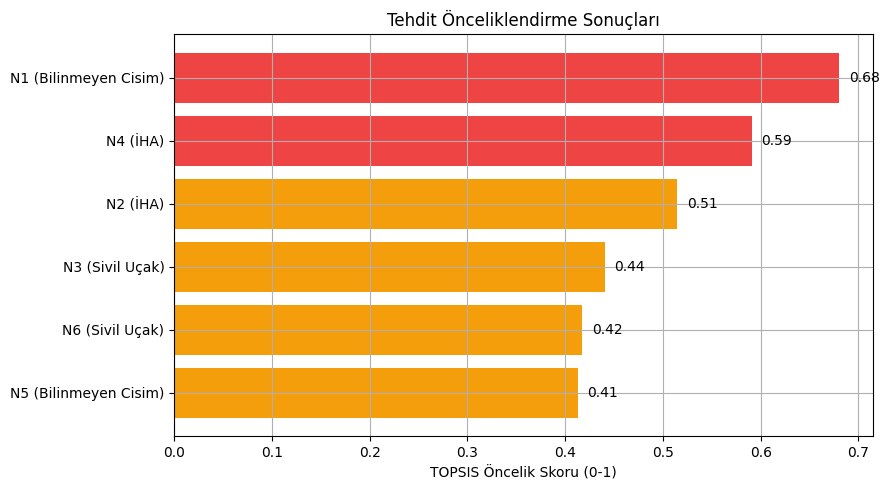

In [6]:
fig, ax = plt.subplots()
renkler = ['#ef4444' if s > 0.55 else '#f59e0b' if s > 0.35 else '#22c55e'
           for s in sonuc_tablosu['Oncelik_Skoru']]
bars = ax.barh(sonuc_tablosu['ID'] + ' (' + sonuc_tablosu['Tip'] + ')',
               sonuc_tablosu['Oncelik_Skoru'], color=renkler)
ax.invert_yaxis()
ax.set_xlabel('TOPSIS Öncelik Skoru (0-1)')
ax.set_title('Tehdit Önceliklendirme Sonuçları')
for b, s in zip(bars, sonuc_tablosu['Oncelik_Skoru']):
    ax.text(b.get_width() + 0.01, b.get_y() + b.get_height()/2, f'{s:.2f}', va='center')
plt.tight_layout()
plt.savefig('tehdit_onceliklendirme.png', dpi=120)
plt.show()


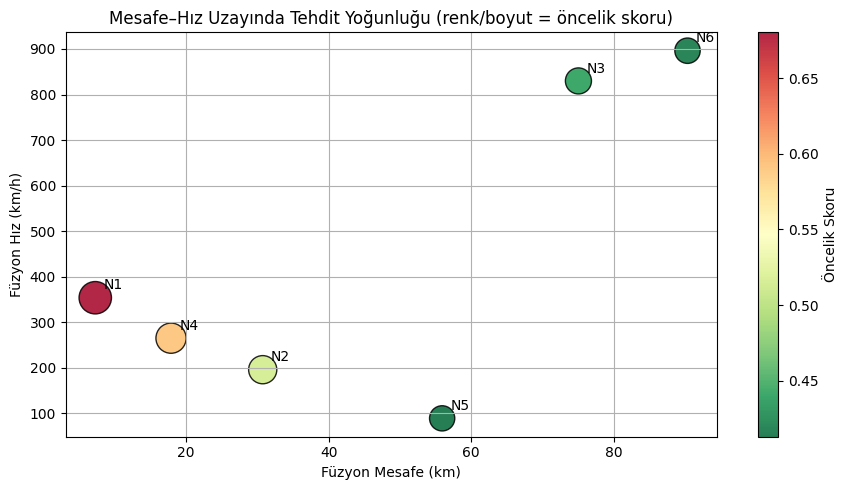

In [7]:
fig, ax = plt.subplots()
sc = ax.scatter(sonuc_tablosu['Fuzyon_Mesafe_km'], sonuc_tablosu['Fuzyon_Hiz_kmh'],
                s=sonuc_tablosu['Oncelik_Skoru'] * 800, c=sonuc_tablosu['Oncelik_Skoru'],
                cmap='RdYlGn_r', edgecolors='black', alpha=0.85)
for _, r in sonuc_tablosu.iterrows():
    ax.annotate(r['ID'], (r['Fuzyon_Mesafe_km'], r['Fuzyon_Hiz_kmh']),
                textcoords='offset points', xytext=(6, 6))
ax.set_xlabel('Füzyon Mesafe (km)')
ax.set_ylabel('Füzyon Hız (km/h)')
ax.set_title('Mesafe–Hız Uzayında Tehdit Yoğunluğu (renk/boyut = öncelik skoru)')
plt.colorbar(sc, label='Öncelik Skoru')
plt.tight_layout()
plt.savefig('mesafe_hiz_dagilimi.png', dpi=120)
plt.show()


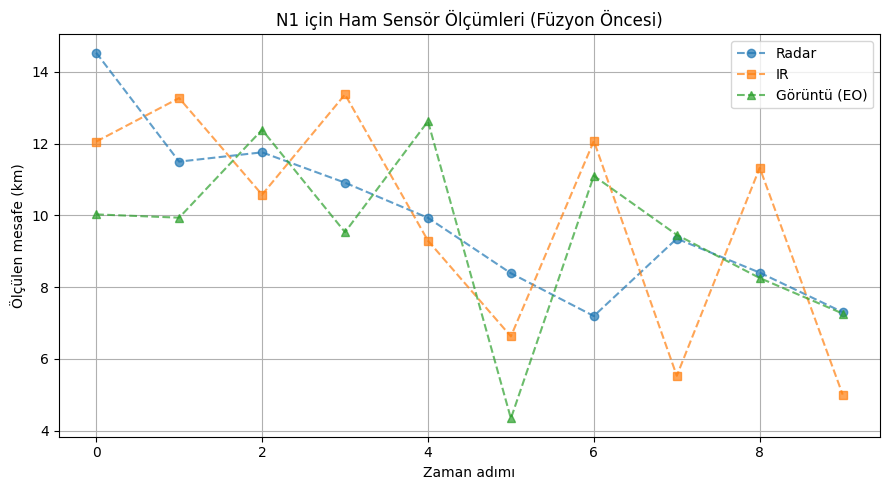

In [8]:
ornek_id = sonuc_tablosu.iloc[0]['ID']
df = sensor_verileri[ornek_id]

fig, ax = plt.subplots()
ax.plot(df['zaman'], df['radar_mesafe'], 'o--', label='Radar', alpha=0.7)
ax.plot(df['zaman'], df['ir_mesafe'], 's--', label='IR', alpha=0.7)
ax.plot(df['zaman'], df['eo_mesafe'], '^--', label='Görüntü (EO)', alpha=0.7)
ax.set_xlabel('Zaman adımı')
ax.set_ylabel('Ölçülen mesafe (km)')
ax.set_title(f'{ornek_id} için Ham Sensör Ölçümleri (Füzyon Öncesi)')
ax.legend()
plt.tight_layout()
plt.savefig('ham_sensor_olcumleri.png', dpi=120)
plt.show()


## 6. Sonuç ve Değerlendirme

- Üç farklı sensörden gelen gürültülü ölçümler, Kalman filtresi ile tek bir tutarlı **mesafe/hız
  tahminine** ve bir **füzyon güven skoruna** indirgenmiştir.
- TOPSIS yöntemi, mesafe, hız, güven skoru ve nesne tipi risk katsayısını birleştirerek nesneleri
  tek bir **öncelik skoru** ile sıralamıştır; bu skor karar destek panosunda görselleştirilmiştir.
- En yüksek öncelikli nesne(ler), yakın mesafe + yüksek hız + yüksek tip riski + yüksek füzyon güveni
  kombinasyonuna sahip olanlardır.
- Bu yaklaşım, kriter ağırlıkları ve sensör sayısı/tipi değiştirilerek farklı karar destek
  senaryolarına (hava trafik önceliklendirme, afet müdahalesi, üretimde arıza önceliklendirme vb.)
  kolayca uyarlanabilir.

### Geliştirme Fikirleri
- Çoklu hedef takibi için Extended/Unscented Kalman Filtresi veya çoklu-hedef veri ilişkilendirme
  (data association) eklenmesi.
- TOPSIS yerine/yanında AHP ile ağırlıkların uzman görüşüyle daha sistematik belirlenmesi.
- Gerçek zamanlı akan veri için canlı (streaming) bir dashboard (ör. Plotly Dash / Streamlit).
